# Patch-Based Inference: Deploying on New Scans

> Sliding-window inference for 3D medical image segmentation using fastMONAI's `PatchInferenceEngine`.

This tutorial deploys the model trained on all labeled data and runs it on **new, unlabeled scans** (the Decathlon Heart test set). Because the model was trained on every labeled case, there is no held-out ground truth to score against here, so we predict and visualize rather than compute metrics. The performance estimate comes from the cross-validation in the prerequisite notebook.

The patch-based inference pipeline:

1. **GridSampler**: Extracts overlapping patches from each input volume
2. **Model**: Predicts on each patch
3. **GridAggregator**: Reconstructs the full volume with Hann windowing for smooth boundaries

**Prerequisites**: Run [12b_tutorial_patch_cross_validation.ipynb](12b_tutorial_patch_cross_validation.ipynb) first to cross-validate, train the final model on all data, and export `models/final_learner.pkl` and `patch_config.json`.

[![Google Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MMIV-ML/fastMONAI/blob/main/nbs/12c_tutorial_patch_inference.ipynb)

In [ ]:
#| hide
#Install `fastMONAI` if notebook is running on Google Colab
try:
    import google.colab
    %pip install fastMONAI
    from fastMONAI.utils import print_colab_gpu_info
    print_colab_gpu_info()
except:
    print('Running locally')

Running locally


In [ ]:
from fastMONAI.vision_all import *

from monai.apps import DecathlonDataset

### Load new scans

Load the Decathlon Heart **test** set (`imagesTs/`) the same way as the standard [inference tutorial](11f_tutorial_inference.ipynb). These scans have no labels, which is exactly the deployment setting: we run the model on data it has never seen and for which no ground truth exists.

In [ ]:
path = Path('../data')
path.mkdir(exist_ok=True)

In [ ]:
task = "Task02_Heart"
test_data = DecathlonDataset(root_dir=path, task=task, section="test",
    download=True, cache_num=0, num_workers=3)

2026-06-30 13:36:07,781 - INFO - Verified 'Task02_Heart.tar', md5: 06ee59366e1e5124267b774dbd654057.


2026-06-30 13:36:07,781 - INFO - File exists: ../data/Task02_Heart.tar, skipped downloading.


2026-06-30 13:36:07,782 - INFO - Non-empty folder exists in ../data/Task02_Heart, skipped extracting.


In [ ]:
test_imgs = [data['image'] for data in test_data.data]
print(f"New scans to segment: {len(test_imgs)}")
test_imgs[:5]

New scans to segment: 10


['../data/Task02_Heart/imagesTs/la_015.nii.gz',
 '../data/Task02_Heart/imagesTs/la_025.nii.gz',
 '../data/Task02_Heart/imagesTs/la_013.nii.gz',
 '../data/Task02_Heart/imagesTs/la_001.nii.gz',
 '../data/Task02_Heart/imagesTs/la_027.nii.gz']

### Load configuration

Load the patch configuration saved during training. This ensures preprocessing consistency:

- **apply_reorder**: Whether to reorder to RAS+ orientation
- **target_spacing**: Target voxel spacing for resampling
- **patch_size, patch_overlap, aggregation_mode**: Inference parameters

Mismatched preprocessing parameters will produce incorrect predictions, for example mirrored or rotated outputs.

In [ ]:
config_dict = load_patch_variables('patch_config.json')
print("Loaded configuration:")
for k, v in config_dict.items():
    print(f"  {k}: {v}")

Loaded configuration:
  patch_size: [160, 160, 80]
  patch_overlap: 0.5
  aggregation_mode: hann
  apply_reorder: True
  target_spacing: [1.25, 1.25, 1.37]
  sampler_type: label
  label_probabilities: {0: 0.5, 1: 0.5}
  samples_per_volume: 8
  queue_length: 300
  queue_num_workers: 4
  keep_largest_component: True
  normalization: [{'name': 'ZNormalization', 'masking_method': 'foreground', 'channel_wise': True}]


In [ ]:
patch_config = PatchConfig(**config_dict)

### Load the final model

Load the exported learner trained on all labeled data in the prerequisite notebook. It contains both the model architecture and the trained weights.

**Two options:**
1. **Local file**: Load `models/final_learner.pkl` exported by the cross-validation notebook
2. **MLflow**: Download `final_learner.pkl` from the final run's artifacts (for experiment-tracking workflows)

In [ ]:
# Option 1: Load from local file
learn = load_learner('models/final_learner.pkl')

# Option 2: Load from MLflow (uncomment to use)
# import mlflow
# run_id = "your_run_id"  # the final_all_data run, from the MLflow UI
# learner_path = mlflow.artifacts.download_artifacts(run_id=run_id, artifact_path="model/final_learner.pkl", dst_path="./")
# learn = load_learner(learner_path)

model = learn.model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
model.eval()

print(f"Loaded model: {model.__class__.__name__}")
print(f"Device: {device}")

Loaded model: UNet
Device: cuda


load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.


### Normalization (loaded from the config)

Normalization was saved in the `PatchConfig` during training, so it is already present in the
loaded `patch_config` and is applied automatically. Nothing to re-specify here.

> If predictions appear mirrored, rotated, or wrong, check that
> `apply_reorder`, `target_spacing`, and `normalization` in the loaded config match training.
> To override, pass `pre_inference_tfms=` explicitly (e.g. for non-serializable transforms).

In [ ]:
# Normalization is already in the loaded config and applied automatically:
print("Normalization from config:", patch_config.normalization)

Normalization from config: [{'name': 'ZNormalization', 'masking_method': 'foreground', 'channel_wise': True}]


### Create PatchInferenceEngine

The engine runs the sliding-window inference pipeline:
1. Load and preprocess the image (reorder, resample, normalize)
2. Pad if image is smaller than patch size
3. Extract overlapping patches with GridSampler
4. Predict on batches of patches
5. Reconstruct full volume with GridAggregator using Hann windowing

In [ ]:
engine = PatchInferenceEngine(
    learner=model,  
    config=patch_config,
    sw_batch_size=4
)

### Single image inference

Use `engine.predict()` to predict on a single image.

In [ ]:
test_path = test_imgs[0]
pred, affine = engine.predict(test_path, return_affine=True)
print(f"Input: {test_path}")
print(f"Prediction shape: {pred.shape}")
print(f"Unique values: {torch.unique(pred).tolist()}")

Input: ../data/Task02_Heart/imagesTs/la_015.nii.gz
Prediction shape: torch.Size([1, 320, 320, 100])
Unique values: [0, 1]


### Batch inference

Use `patch_inference()` to predict on multiple images with optional NIfTI output.

In [ ]:
predictions = patch_inference(
    learner=model,  # the engine also accepts a raw model (here learn.model)
    config=patch_config,
    file_paths=test_imgs,
    save_dir='predictions/patch_heart',
    progress=True
)

print(f"\nGenerated {len(predictions)} predictions")
print(f"Saved to: predictions/patch_heart/")

Patch inference:   0%|          | 0/10 [00:00<?, ?it/s]


Generated 10 predictions
Saved to: predictions/patch_heart/


## Optional: ensemble the 5 cross-validation models

The cross-validation notebook ([12b](12b_tutorial_patch_cross_validation.ipynb)) trains one model per fold. Instead of deploying only the single final model, you can run all five fold models together as an **ensemble** and average their predictions. This is the standard nnU-Net-style approach: it usually gives a small accuracy gain and more robust, better-calibrated masks, at the cost of running inference once per model.

fastMONAI uses **soft voting**. Each model runs the full sliding-window pass, the per-patch class probabilities are averaged across the models, and the final label map comes from a single `argmax` on the averaged probabilities (never a vote on discrete masks). Averaging happens inside `PatchInferenceEngine`, so you just pass a **list of models** instead of one. Because each volume is preprocessed once and every model runs on the shared patches, memory and preprocessing stay close to single-model inference.

> **Prerequisite**: this section uses the per-fold checkpoints `models/best_fold_1.pth ... best_fold_5.pth` saved by 12b's cross-validation part. Run that first if you skipped it.

### Load the five fold models

12b's `EMACheckpoint` saved each fold's best weights as `models/best_fold_{i}.pth` (weights only, not an exported learner). We rebuild each model from the final learner's architecture (the folds use the identical UNet) and load each fold's weights into it.

In [ ]:
from copy import deepcopy

# The 5 CV fold checkpoints from 12b (Part 1). EMACheckpoint saved each fold's best weights
# as models/best_fold_{i}.pth (weights only), so we rebuild each model from the final learner's
# architecture (identical UNet) and load each fold's weights into it.
fold_paths = [Path(f'models/best_fold_{i}.pth') for i in range(1, 6)]

if all(p.exists() for p in fold_paths):
    fold_models = []
    for p in fold_paths:
        m = deepcopy(learn.model)
        m.load_state_dict(torch.load(p, map_location=device))
        m.to(device).eval()
        fold_models.append(m)
    print(f"Loaded {len(fold_models)} fold models for ensembling")
else:
    fold_models = None
    missing = [str(p) for p in fold_paths if not p.exists()]
    print("Fold checkpoints not found:", missing)
    print("Run 12b's cross-validation section first. Skipping the ensemble demo.")

# Alternative: load each fold's exported learner from its MLflow run instead of local weights
# (each CV fold run logs model/best_learner.pkl), mirroring the single-model MLflow option above:
# fold_models = [load_learner(fold_pkl).model for fold_pkl in fold_learner_pkls]

### Run the ensemble

Pass the list of fold models to `patch_inference` (or `PatchInferenceEngine`) exactly like a single model. Predictions are written to a separate folder so they sit alongside the single-model outputs.

In [ ]:
if fold_models is not None:
    # Pass the list of models: the engine averages their softmax probabilities per patch
    # (soft voting), then applies a single argmax + keep_largest_component, as in training.
    ensemble_predictions = patch_inference(
        fold_models,
        config=patch_config,
        file_paths=test_imgs,
        save_dir='predictions/patch_heart_ensemble',
        progress=True
    )
    print(f"\nEnsemble: generated {len(ensemble_predictions)} predictions")
    print("Saved to: predictions/patch_heart_ensemble/")

    # Single-image ensemble: same call, just pass the list to PatchInferenceEngine
    ensemble_engine = PatchInferenceEngine(fold_models, config=patch_config, sw_batch_size=4)
    pred_ens = ensemble_engine.predict(test_imgs[0])
    print(f"Ensemble prediction shape: {pred_ens.shape}, unique values: {torch.unique(pred_ens).tolist()}")

### Visualize predictions

There is no ground truth for these scans, so we overlay the predicted mask on the input volume and inspect it qualitatively with TorchIO's `Subject.plot`.

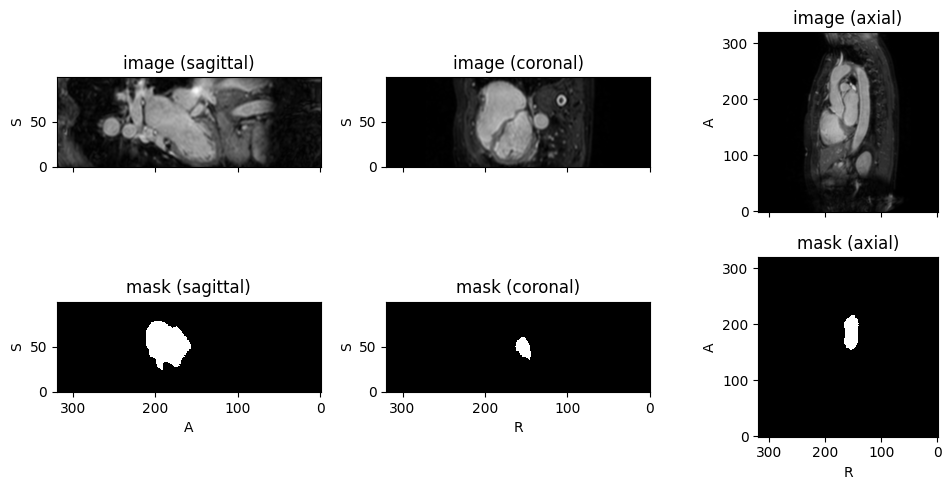

In [ ]:
from torchio import Subject, ScalarImage, LabelMap

idx = 0
img_fn = test_imgs[idx]
# patch_inference saves each prediction as '<stem>_pred.nii.gz' in save_dir, in the input's voxel space.
pred_fn = Path('predictions/patch_heart') / Path(img_fn).name.replace('.nii.gz', '_pred.nii.gz')

subject = Subject(image=ScalarImage(img_fn), mask=LabelMap(pred_fn))
subject.plot(figsize=(10, 5))

### Summary

In this tutorial, we deployed the final patch-based model on new, unlabeled scans:

1. **`load_patch_variables()`**: Load the configuration saved during training so preprocessing matches exactly
2. **Load the exported learner**: `load_learner('models/final_learner.pkl')` loads the all-data model exported by the cross-validation notebook, and we pass its `learn.model` to `PatchInferenceEngine`
3. **`PatchInferenceEngine`**: Sliding-window inference with GridSampler and GridAggregator
4. **`patch_inference()`**: Batch inference with NIfTI output, then qualitative visualization with TorchIO's `Subject.plot`